# OPM Example Without a Structural MRI (Parcel Level)

Start-to-end example script for applying the canonical HMM to OPM data **without an individual structural MRI**. Instead, we scale a template MRI (MNI152) to match the participant's 3D head scan (e.g., EinScan) headshape points.

If you have an individual structural MRI, see the main `opm.ipynb` tutorial instead.

#### Input Data

We will use data in BIDS format:
```
BIDS/
├── ...
├── sub-05/
│   ├── meg/
│   │   ├── sub-05_ses-01_task-braille_run-01_meg.fif
│   │   ├── ...
```

Note, we do **not** need an `anat/` directory with a structural MRI.

#### Import Packages

In [1]:
import numpy as np
from pathlib import Path

import mne
mne.viz.set_3d_backend("notebook")

from modules import hmm

from osl_dynamics import analysis, inference
from osl_dynamics.meeg import amm, preproc, rhino, source_recon, parcellation
from osl_dynamics.data import Data
from osl_dynamics.files import mni152_surfaces
from osl_dynamics.utils import plotting
from osl_dynamics.utils.filenames import OSLFilenames

Using notebook 3d backend.


2026-03-28 17:59:17.719076: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### Session Info

Let's specify which session in the `BIDS` directory we wish to study.

In [2]:
subject = "05"
session = "01"
task = "braille"
run = "01"
id = f"sub-{subject}_ses-{session}_task-{task}_run-{run}"
print("id:", id)

id: sub-05_ses-01_task-braille_run-01


## 1. Preprocessing

Now, we can clean the sensor data. We will use MNE to do this. Let's load the raw fif file.

In [3]:
raw_file = f"BIDS/sub-{subject}/meg/{id}_meg.fif"
raw = mne.io.read_raw_fif(raw_file, preload=True)

Opening raw data file BIDS/sub-05/meg/sub-05_ses-01_task-braille_run-01_meg.fif...
    Range : 0 ... 502399 =      0.000 ...  1339.731 secs
Ready.
Reading 0 ... 502399  =      0.000 ...  1339.731 secs...


#### AMM Interference Rejection

The Adaptive Multipole Model (AMM) separates brain signals from environmental interference by decomposing the data into internal (brain) and external (interference) prolate spheroidal harmonics. This is the OPM equivalent of MaxFilter for Elekta MEG systems and should be applied first, before any temporal filtering or downsampling.

See [Tierney et al. (2024)](https://doi.org/10.1002/hbm.26596).

In [4]:
raw, amm_info = amm.apply_amm(raw)

  AMM: 192 MEG channels, li=9, le=2, window=10.0s, corr_lim=0.98
  Spheroid centre: [ 0.50384878 -5.57332401 -7.10799454] mm
  Spheroid radii: [ 98.3273027  115.75827824  98.3273027 ] mm
  Longest axis: 1 (Y)
  Shrunk radii: [ 92.3273027  109.75827824  92.3273027 ] mm
  a=109.8 mm, b=92.3 mm
  Computing external harmonics...
  Computing internal harmonics...
  Building projectors...
  M_int rank: 99 (of 99 columns)
  ||Pin @ ext|| = 1.72e-14
  Processing 134 windows...
  AMM complete.


Now, let's perform some minimal preprocessing: downsampling and filtering.

In [5]:
raw = raw.crop(tmax=60)
raw = raw.resample(sfreq=250)
raw = raw.filter(l_freq=4, h_freq=40, method="iir", iir_params={"order": 5, "ftype": "butter"})
raw = raw.notch_filter([50, 100])

Finding events on: A1, bra-0, A3, Rig, A5, A6, A7, A8, bra-1, A10, bra-2, A12, Lef, A14, Bra, A16, T1, key, T3, T4, T5, T6, T7, T8, T9, T10, T11
592 events found on stim channel bra-0
Event IDs: [2]
1 event found on stim channel Rig
Event IDs: [3]
37 events found on stim channel bra-1
Event IDs: [2]
22 events found on stim channel bra-2
Event IDs: [2]
3 events found on stim channel Lef
Event IDs: [3]
18 events found on stim channel Bra
Event IDs: [3]
7 events found on stim channel key
Event IDs: [1]
Trigger channel T6 has a non-zero initial value of 1 (consider using initial_event=True to detect this event)
Trigger channel T8 has a non-zero initial value of 1 (consider using initial_event=True to detect this event)
Trigger channel T9 has a non-zero initial value of 1 (consider using initial_event=True to detect this event)
Trigger channel T11 has a non-zero initial value of 1 (consider using initial_event=True to detect this event)
Finding events on: A1, bra-0, A3, Rig, A5, A6, A7, A8,

/var/folders/vm/c_6vf1wd0nlcmwq_xc40_d180000gq/T/ipykernel_11748/2831229979.py:2: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw = raw.resample(sfreq=250)


Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)



We also want to detect bad segments. Here, we use an automated G-ESD algorithm to do this.

In [6]:
raw = preproc.detect_bad_segments(raw, picks="mag", significance_level=0.1)
raw = preproc.detect_bad_segments(raw, picks="mag", mode="diff", significance_level=0.1)
raw = preproc.detect_bad_segments(raw, picks="mag", metric="kurtosis", significance_level=0.1)


Bad segment detection
---------------------
Modality: mag
Mode: None
Metric: std
Significance level: 0.1
Maximum fraction: 0.1
Found 2 bad segments: 4.0/60.0 seconds rejected (6.7%)

Bad segment detection
---------------------
Omitting 1000 of 15001 (6.67%) samples, retaining 14001 (93.33%) samples.
Modality: mag
Mode: diff
Metric: std
Significance level: 0.1
Maximum fraction: 0.1
Found 0 bad segments: 0.0/60.0 seconds rejected (0.0%)

Bad segment detection
---------------------
Omitting 1000 of 15001 (6.67%) samples, retaining 14001 (93.33%) samples.
Modality: mag
Mode: None
Metric: kurtosis
Significance level: 0.1
Maximum fraction: 0.1
Found 1 bad segments: 2.0/60.0 seconds rejected (3.3%)


Setting 1500 of 15001 (10.00%) samples to NaN, retaining 13501 (90.00%) samples.


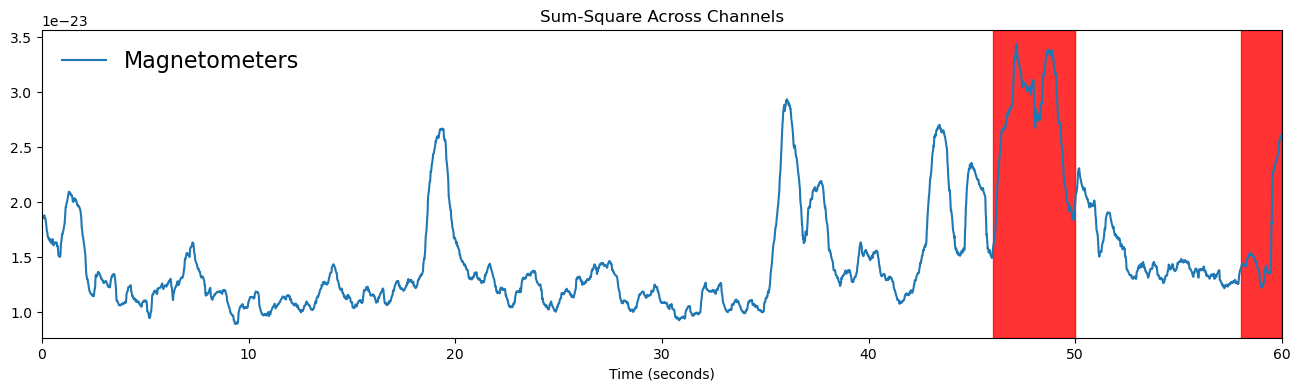

In [7]:
preproc.plot_sum_square_time_series(raw)

And finally, let's also detect bad channels based on the standard deviation.

In [8]:
raw = preproc.detect_bad_channels(raw, picks="mag", significance_level=0.1)


Bad channel detection
---------------------
0 bad channels:
[]


Omitting 1500 of 15001 (10.00%) samples, retaining 13501 (90.00%) samples.


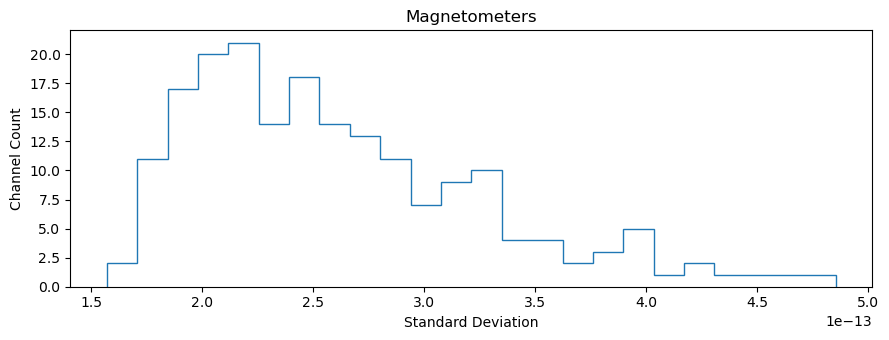

In [9]:
preproc.plot_channel_stds(raw)

#### ICA Artefact Rejection

We use MEGNet automatic labelling (via `mne-icalabel`) to identify and remove artefact components (e.g., cardiac, eye blinks). MEGNet was trained on magnetometer topographies, making it well suited for OPM data.

In [10]:
raw, ica, ic_labels = preproc.ica_label(raw, picks="mag", method="megnet")


ICA artefact rejection
----------------------
Method: megnet
Picks: mag
Components: 20
Threshold: 0.5
Filtering data copy (1-100 Hz) for ICA fitting...
Fitting ICA...
Fitting ICA to data using 192 channels (please be patient, this may take a while)
Omitting 1500 of 15001 (10.00%) samples, retaining 13501 (90.00%) samples.
Selecting by number: 20 components
Computing Extended Infomax ICA
Fitting ICA took 6.2s.
Labelling components...
Setting 1500 of 15001 (10.00%) samples to NaN, retaining 13501 (90.00%) samples.
Effective window size : 8.192 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.


/Users/gohil/packages/osl-dynamics/osl_dynamics/meeg/preproc.py:443: RuntimeWarning: The provided raw instance is not filtered between 1 and 100 Hz. MEGnet was designed to classify features extracted from an MEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw instances). The classification performance might be negatively impacted.
  ic_labels = label_components(raw_fit, ica, method=method)
/Users/gohil/packages/miniforge3/envs/osld/lib/python3.12/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 2000, using nperseg = 2000
  return _func(*args, **kwargs)
/Users/gohil/packages/miniforge3/envs/osld/lib/python3.12/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1, using nperseg = 1
  return _func(*args, **kwargs)


No artefact components found.


One of the major differences when working with data from the CERCA Magnetics system is the inclusion of headshape data from the handheld 3D EinScan. This usually gives a very dense mesh of the head, face, and neck. A lot of the points are redundant (making the ICP algorithm we will use in coregistration slower). Let's decimate the headshape.

In [11]:
raw = preproc.decimate_headshape_points(raw)


Decimate headshape points
-------------------------
Digitization points: (4786, 3)
Removing points below zlim
Using gridaverage


And finally we save the preprocessed data.

In [12]:
preproc_file = Path(f"BIDS/derivatives/preprocessed/{id}_preproc-raw.fif")
preproc_file.parent.mkdir(parents=True, exist_ok=True)
raw.save(preproc_file, overwrite=True)

Overwriting existing file.
Writing /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/preprocessed/sub-05_ses-01_task-braille_run-01_preproc-raw.fif
Overwriting existing file.
Closing /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/preprocessed/sub-05_ses-01_task-braille_run-01_preproc-raw.fif
[done]


[PosixPath('/Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/preprocessed/sub-05_ses-01_task-braille_run-01_preproc-raw.fif')]

## 2. Scale Surfaces to Headshape

This step replaces the need for an individual structural MRI. We take the pre-computed MNI152 surfaces and scale them to match the participant's head shape, as captured by the EinScan headshape points stored in the FIF file.

The method:
1. Aligns the EinScan headshape to the template scalp using fiducials + ICP.
2. Computes an affine transform (with anisotropic scaling) from surface correspondences.
3. Applies the transform to the template MRI and surfaces.

If you have an individual structural MRI, use `rhino.extract_surfaces` instead and see the main `opm.ipynb` tutorial.

In [13]:
surfaces_dir = f"BIDS/derivatives/anat_surfaces/sub-{subject}"

rhino.scale_surfaces_to_headshape(
    preproc_file=str(preproc_file),
    surfaces_dir=mni152_surfaces.directory,
    outdir=surfaces_dir,
)


Scaling surfaces to headshape
-----------------------------
Loading headshape from BIDS/derivatives/preprocessed/sub-05_ses-01_task-braille_run-01_preproc-raw.fif
Found 484 headshape points
Computing initial alignment via fiducials
Running ICP with 10 initialisations
ICP found better xform, error=3.571026964162582
Computing affine transform from surface correspondences
  Scaling: x=1.009 y=1.019 z=0.989
Saving scaled MRI and surfaces
Overwriting existing file.
Overwriting existing file.
Surfaces saved: /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/anat_surfaces/sub-05


'/Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/anat_surfaces/sub-05'

## OSL Output Files

Now we have the preprocessed sensor data and the scaled MRI surfaces. We can perform an 'OSL' source reconstruction. This involves creating many files. Let's create an object (container) to keep track of all the files.

In [14]:
fns = OSLFilenames(
    outdir="BIDS/derivatives/osl",
    id=id,
    preproc_file=f"BIDS/derivatives/preprocessed/{id}_preproc-raw.fif",
    surfaces_dir=surfaces_dir,
)
print(fns)

OSLFilenames for sub-05_ses-01_task-braille_run-01:
  Output directory:  BIDS/derivatives/osl
  Preprocessed file: BIDS/derivatives/preprocessed/sub-05_ses-01_task-braille_run-01_preproc-raw.fif
  Surfaces directory: BIDS/derivatives/anat_surfaces/sub-05
  BEM directory:     BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/bem
  Coreg directory:   BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg
    └─ Forward model: BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/model-fwd.fif
  Source directory:  BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/src
    └─ lcmv filters:  BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/src/filters-lcmv.h5


There are some files which we have already generated like the preprocessed fif file and the surfaces. Other files we will create in the following steps.

Now let's extract the headshape from the preprocessed fif file and coregister the MEG and MRI.

## 3. Coregistration

Next we use the EinScan headshape points/fiducials to coregister the OPM sensor space to the scaled MRI.


Extracting fiducials/headshape points from fif info
---------------------------------------------------
Saved: BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/head_nasion.txt
Saved: BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/head_rpa.txt
Saved: BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/head_lpa.txt
Saved: BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/head_headshape.txt

Running coregistration (HEAD (polhemus) -> MRI)
-----------------------------------------------
The MRI-derived nose is not going to be used to aid coregistration.
Please ensure that the headshape points do not include the nose
Creating RawArray with float64 data, n_channels=219, n_times=1
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.
Overwriting existing file.
Writing /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/info-raw.fif
Overwriting existing file.
Closing /Users/gohil/Desktop/Ca

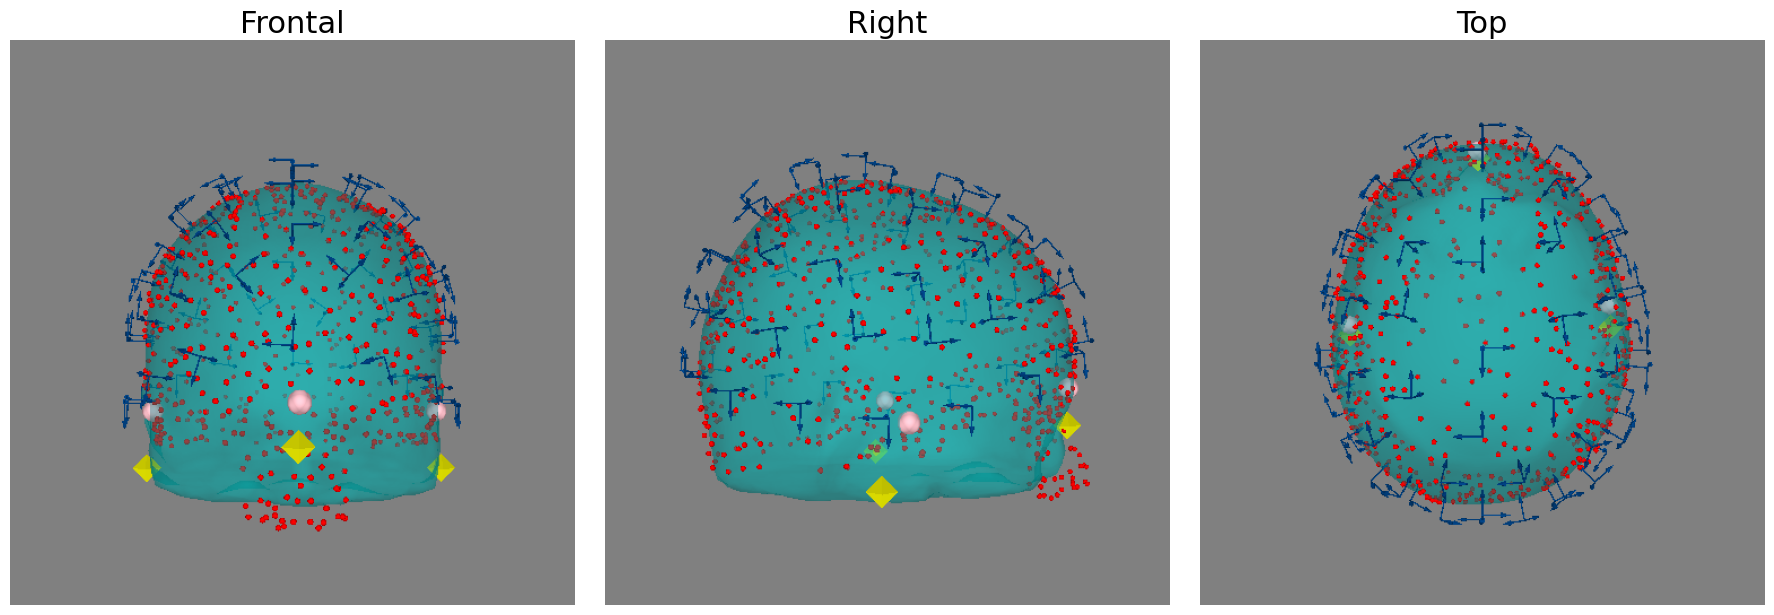

Coregistration complete.


In [15]:
rhino.extract_fiducials_and_headshape_from_fif(fns)
rhino.coregister_head_and_mri(fns, use_nose=False, show=True)

Check that the headshape points (red) sit on the scalp surface and the sensors (blue) surround the head correctly.

If the coregistration looks off we need to fix it before moving on. Some things we can try tweaking the headshape points and/or fiducials (these are in text files in `fns.coreg_dir`).

Next, we calculate the forward model for MEG. Here, we're using a 'Single Layer' (Single Shell) head model and a dipole grid resolution of 8mm.

In [16]:
rhino.forward_model(fns, model="Single Layer", gridstep=8)


Calculating forward model
-------------------------
Overwriting existing file.
Using bet_inskull_surf_file for single shell surface
Overwriting existing file.
Overwriting existing file.
Surface CM = (   0.6  -20.2    6.3) mm
Surface fits inside a sphere with radius   96.2 mm
Surface extent:
    x =  -71.2 ...   73.0 mm
    y = -108.4 ...   74.9 mm
    z =  -70.6 ...   84.8 mm
Grid extent:
    x =  -72.0 ...   80.0 mm
    y = -112.0 ...   80.0 mm
    z =  -72.0 ...   88.0 mm
10500 sources before omitting any.
6836 sources after omitting infeasible sources not within 0.0 - 96.2 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    4.0 mm away (will take a few...)
Checking surface interior status for 6836 points...
    Found  843/6836 points inside  an interior sphere of radius   46.9 mm
    Found    0/6836 points outside an exterior sphere of radius   96.2 mm
    Found 2808/5993 points outside using surface Qhull
    Found  223/3185 p

## 4. Source Reconstruction

Now we are ready to create an LCMV beamformer. We will use a unit-noise-gain-invariant beamformer. Note, for OPMs we use `chantypes="mag"` since OPMs are magnetometers.

In [17]:
source_recon.lcmv_beamformer(fns, raw, chantypes="mag", rank={"mag": 100})


Making LCMV beamformer
----------------------
Reading forward solution from /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (3328 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Using up to 300 segments
Number of samples used : 13500
[done]
Variance for chantype mag is 7.277706285268264e-26
Excluding 27 channel(s) missing from the provided forward operator and/or covariance matrices
Computing rank from covariance with rank={'mag': 100}
Computing rank from covariance with rank='info'
    MAG: rank 192 after 0 projectors applied to 192 channels
Making LCMV beamformer with data cov rank {'mag': 100}
Making LCMV beamformer with noise cov rank {'mag': 192}
Computing inverse 

Next, we calculate voxel data by applying the beamformer weights to the sensor data. Note, the following function returns the voxel data  (and coordinates) in MNI space.

In [18]:
voxel_data, voxel_coords = source_recon.apply_lcmv_beamformer(fns, raw)


Applying LCMV beamformer
------------------------
Omitting 1500 of 15001 (10.00%) samples, retaining 13501 (90.00%) samples.
Reading forward solution from /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/coreg/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (3328 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
spatial_resolution = 8 mm
mask_file: BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/src/MNI152_T1_8mm_brain.nii.gz
Finding nearest neighbour in resampled MNI space
Applying LCMV beamformer complete.


## 5. Parcellation

Now we have the voxel data, we can parcellate.

In [19]:
parcellation_file = "atlas-Glasser_nparc-52_space-MNI_res-8x8x8.nii.gz"

parcel_data = parcellation.parcellate(
    fns,
    voxel_data,
    voxel_coords,
    method="spatial_basis",
    orthogonalisation="symmetric",
    parcellation_file=parcellation_file,
)

parc_fif = f"BIDS/derivatives/osl/{id}/lcmv-parc-raw.fif"
parcellation.save_as_fif(
    parcel_data,
    raw,
    extra_chans="stim",
    filename=parc_fif,
)

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-03-28 18:01:44 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-03-28 18:01:44 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1



Parcellating data
-----------------
gridstep = 8 mm


Resampled parcellation: BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/src/atlas-Glasser_nparc-52_space-MNI_res-8x8x8_8mm.nii.gz
Finding nearest neighbour voxel
Calculating parcel time courses with spatial_basis
Performing symmetric orthogonalisation
Saving BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/lcmv-parc-raw.fif
Omitting 1500 of 15001 (10.00%) samples, retaining 13501 (90.00%) samples.
Creating RawArray with float64 data, n_channels=52, n_times=15001
    Range : 0 ... 15000 =      0.000 ...    60.000 secs
Ready.
Creating RawArray with float64 data, n_channels=27, n_times=15001
    Range : 0 ... 15000 =      0.000 ...    60.000 secs
Ready.
Overwriting existing file.
Writing /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/lcmv-parc-raw.fif
Overwriting existing file.
Closing /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/lcmv-parc-raw.fif
[done]


The final data is saved in the file `lcmv-parc-raw.fif`. The parcellated data is saves as a `'misc'` channel type.

The last thing we will do is plot the PSD of the parcel data to check the source reconstruction looks reasonable.

Opening raw data file BIDS/derivatives/osl/sub-05_ses-01_task-braille_run-01/lcmv-parc-raw.fif...
    Range : 0 ... 15000 =      0.000 ...    60.000 secs
Ready.
Omitting 1500 of 15001 (10.00%) samples, retaining 13501 (90.00%) samples.


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-03-28 18:02:10 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


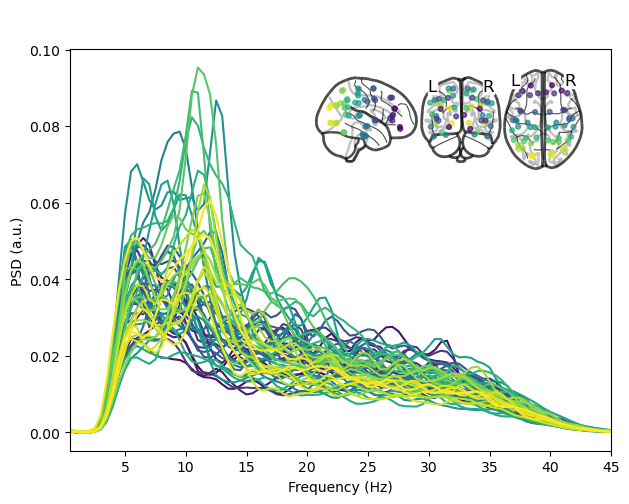

In [20]:
parcellation.plot_psds(parc_fif, parcellation_file=parcellation_file)

We should see alpha (~10 Hz) activity is posterior in the brain if not there may be an issue. Although note, there is a lot of subject variability, some subjects don't exhibit strong alpha oscillations.

## 6. Prepare Data for the Canonical HMM

Here, we prepare the data by aligning the sign of the parcel time courses to the template session from the canonical HMM and then perform time-delay embedding and PCA. Finally, we standardise the data. This is all done with the `prepare_data_for_canonical_hmm` function.

In [21]:
# Load and prepare the data
data = Data(parc_fif, picks="misc", reject_by_annotation="omit")
data = hmm.prepare_data_for_canonical_hmm(data, parcellation="Glasser52")

# Save
hmm_dir = f"BIDS/derivatives/hmm/{id}"
data.save(hmm_dir)

Loading files:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating covariances:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-28 18:02:13 INFO osl-dynamics [base.py:1196:align_channel_signs]: Aligning channel signs across sessions
2026-03-28 18:02:59 INFO osl-dynamics [base.py:1157:_find_and_apply_flips]: Session 0, Init 0, best correlation with template: 0.096
2026-03-28 18:03:39 INFO osl-dynamics [base.py:1157:_find_and_apply_flips]: Session 0, Init 1, best correlation with template: 0.100
2026-03-28 18:04:22 INFO osl-dynamics [base.py:1157:_find_and_apply_flips]: Session 0, Init 2, best correlation with template: 0.101


TDE-PCA:   0%|          | 0/1 [00:00<?, ?it/s]

Standardize:   0%|          | 0/1 [00:00<?, ?it/s]

Saving data:   0%|          | 0/1 [00:00<?, ?it/s]

## 7. Fit the Canonical HMM

First, we load a canonical HMM.

In [22]:
model = hmm.load_canonical_hmm(n_states=8, parcellation="Glasser52")
model.summary()

Model: "HMM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, 400, 120)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ means               │ (8, 120)          │        960 │ data[0][0]        │
│ (VectorsLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ covs                │ (8, 120, 120)     │     58,080 │ data[0][0]        │
│ (CovarianceMatrice… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ll                  │ (None, 400, 8)    │          0 │ data[0][0],       │
│ (SeparateLogLikeli… │                   │            │ means[0][0],      │
│                     │                   │            │ covs[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hid_state_inf       │ [(None, 400, 8),  │         72 │ ll[0][0]          │
│ (HiddenMarkovState… │ (None, 400, 8,    │            │                   │
│                     │ 8)]               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ll_loss             │ (1)               │          0 │ ll[0][0],         │
│ (SumLogLikelihoodL… │                   │            │ hid_state_inf[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 59,112 (230.91 KB)

 Trainable params: 58,152 (227.16 KB)

 Non-trainable params: 960 (3.75 KB)

Now let's infer the probability of each state being active at a given time point in the new data.

2026-03-28 18:04:23 INFO osl-dynamics [inf_mod_base.py:1185:get_alpha]: Getting alpha


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Creating RawArray with float64 data, n_channels=8, n_times=15001
    Range : 0 ... 15000 =      0.000 ...    60.000 secs
Ready.
Creating RawArray with float64 data, n_channels=27, n_times=15001
    Range : 0 ... 15000 =      0.000 ...    60.000 secs


2026-03-28 18:04:31.190942: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Ready.
Overwriting existing file.
Writing /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/hmm/sub-05_ses-01_task-braille_run-01/alp_raw.fif
Overwriting existing file.
Closing /Users/gohil/Desktop/Canonical-HMM-Networks/BIDS/derivatives/hmm/sub-05_ses-01_task-braille_run-01/alp_raw.fif
[done]


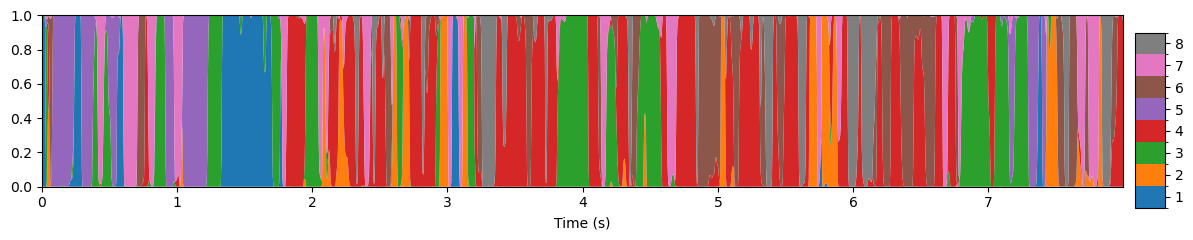

In [23]:
# State probability time course
alp = model.get_alpha(data)

# Save
alp_raw = inference.modes.convert_to_mne_raw(alp, parc_fif, n_embeddings=data.n_embeddings)
alp_raw.save(f"{hmm_dir}/alp_raw.fif", overwrite=True)

# Plot (just the first 8 seconds for visualisation)
fig, ax = plotting.plot_alpha(alp, n_samples=2000, sampling_frequency=250)

## 8. HMM Post-Hoc Analysis

Now we have the state probabilities, we can perform 'post-hoc analysis' where we estimate state-specific quantities of interest such as spectral properties, networks, and summary statistics for dynamics.

See the [osl-dynamics docs](https://osl-dynamics.readthedocs.io/en/latest/documentation.html) for further information and tutorials, as well as code for visualisations.

Let's start with the spectral properties.

In [24]:
# Calculate multitaper
trimmed_data = data.trim_time_series(sequence_length=model.config.sequence_length, prepared=False)
f, psd, coh = analysis.spectral.multitaper_spectra(
    data=trimmed_data,
    alpha=alp,
    sampling_frequency=250,
    frequency_range=[4, 40],
)
print(f.shape)
print(psd.shape)
print(coh.shape)

# Save
np.save(f"{hmm_dir}/f.npy", f)
np.save(f"{hmm_dir}/psd.npy", psd)
np.save(f"{hmm_dir}/coh.npy", coh)

2026-03-28 18:04:32 INFO osl-dynamics [spectral.py:481:multitaper_spectra]: Calculating spectra


(73,)
(8, 52, 73)
(8, 52, 52, 73)


Now let's use the spectra to calculate state-specific networks.

In [25]:
# Power maps
pow_maps = analysis.power.variance_from_spectra(f, psd)
print(pow_maps.shape)
np.save(f"{hmm_dir}/pow_maps.npy", pow_maps)

# Coherence networks
coh_nets = analysis.connectivity.mean_coherence_from_spectra(f, coh)
print(coh_nets.shape)
np.save(f"{hmm_dir}/coh_nets.npy", coh_nets)

(8, 52)
(8, 52, 52)


Finally, let's calculate summary statistics for dynamics.

In [26]:
# Binarise the state probabilities
stc = inference.modes.argmax_time_courses(alp)

# Summary statistics
fo = analysis.post_hoc.fractional_occupancies(stc)
lt = analysis.post_hoc.mean_lifetimes(stc, sampling_frequency=250)
intv = analysis.post_hoc.mean_intervals(stc, sampling_frequency=250)
sr = analysis.post_hoc.switching_rates(stc, sampling_frequency=250)

# Save
np.save(f"{hmm_dir}/fo.npy", fo)
np.save(f"{hmm_dir}/lt.npy", lt)
np.save(f"{hmm_dir}/intv.npy", intv)
np.save(f"{hmm_dir}/sr.npy", sr)